In [1]:
import socket
import json
import time
import copy
import matplotlib.pyplot as plt
import numpy as np
import pyvisa
import skrf as rf
import io
import base64
import serial.tools.list_ports
from urllib.request import urlopen

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()        
ports = serial.tools.list_ports.comports()

#for port in ports:
#    print(f"Port Name:   {port.device}")
#    print(f"Description: {port.description}")
#    print(f"Hardware ID: {port.hwid}")  # Shows USB Vendor ID, Product ID, and Location string


In [6]:
# get physical state of instruments now and pass this over the bridge to the html
instrument_control = {}
instrument_control['message'] = 'media'
file_object = open("instrument-control.json", "w")
file_object.write(json.dumps(instrument_control, indent="\t"))
file_object.close()
instrument_control

{'message': 'media'}

In [7]:
with open("instrument-control.json", "r", encoding="utf-8") as file:
    file_contents = file.read()
instrument_control = json.loads(file_contents)
instrument_control

{'message': 'message here'}

=== LIVE SERVER ACTIVE ===

=== SERVER TERMINATED CLEANLY BY USER ===


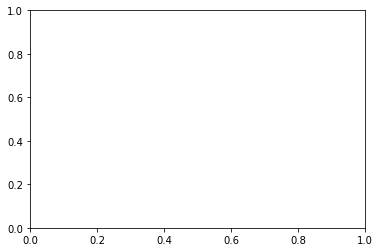

In [12]:
previous_state = copy.deepcopy(instrument_control)
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as server:
    server.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
    server.bind(('127.0.0.1', 8000))
    server.listen(5)
    server.settimeout(0.5)
    print("=== LIVE SERVER ACTIVE ===")
    try:
        while True:
            try:
                conn, addr = server.accept()
            except socket.timeout:
                continue 
            with conn:
                raw_web_input = conn.makefile('r', encoding='utf-8').readline()
                if not raw_web_input:
                    continue
                try:
                    instrument_control = json.loads(raw_web_input.strip())
                except (json.JSONDecodeError, ValueError):
                    pass
                previous_state = copy.deepcopy(instrument_control)
                xdata = np.linspace(0,10,100)
                ydata = np.sin(xdata)
                ydata += 0.1*np.random.randn(len(xdata))
                dataset = {}
                dataset['xdata'] = xdata.tolist()
                dataset['ydata'] = ydata.tolist()
                dataset['xlabel'] = 'x'
                dataset['ylabel'] = 'y'
                dataset['ymin'] = -1.2
                dataset['ymax'] = 1.2
                dataset['instrument_control'] = instrument_control                
                plt.cla()
                plt.figure(figsize=(8, 5))
                plt.plot(xdata, ydata)
                plt.xlim(xdata[0], xdata[-1])
                plt.ylim(dataset['ymin'],dataset['ymax'])
                plt.grid(True)
                plt.xlabel(dataset['xlabel'])
                plt.ylabel(dataset['ylabel'])
                plt.tight_layout()
                img_buf = io.BytesIO()
                plt.savefig(img_buf, format='png')
                plt.close()
                img_buf.seek(0)
                b64_string = base64.b64encode(img_buf.read()).decode('utf-8')
                imagedata = f"data:image/png;base64,{b64_string}"
                dataset['image'] = imagedata                
                payload = json.dumps(dataset) + "\n"
                conn.sendall(payload.encode('utf-8'))
                conn.shutdown(socket.SHUT_WR)

    except KeyboardInterrupt:
        print("\n=== SERVER TERMINATED CLEANLY BY USER ===")

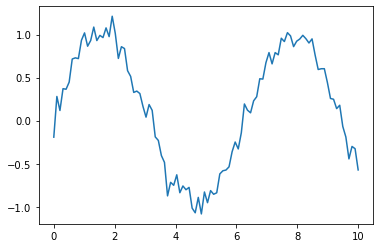

In [23]:
xdata = np.linspace(0,10,100)
ydata = np.sin(xdata)
ydata += 0.1*np.random.randn(len(xdata)) 
plt.plot(xdata,ydata)